In [13]:
import pandas as pd
import numpy as np
df= pd.read_csv('Airline Dataset.csv')

In [14]:
df.head()

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,Continents,Departure Date,Arrival Airport,Pilot Name,Flight Status
0,10856,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,NAM,North America,6/28/2022,CXF,Edithe Leggis,On Time
1,43872,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,North America,12/26/2022,YCO,Elwood Catt,On Time
2,42633,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,Europe,1/18/2022,GNB,Darby Felgate,On Time
3,78493,Dominica,Pyle,Female,71,China,Ottawa / Gatineau Airport,CA,Canada,NAM,North America,9/16/2022,YND,Dominica Pyle,Delayed
4,82072,Bay,Pencost,Male,21,China,Gillespie Field,US,United States,NAM,North America,2/25/2022,SEE,Bay Pencost,On Time


In [15]:
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 0


In [16]:
df = df.drop(['Passenger ID', 'First Name', 'Last Name'], axis=1)
df.head()

,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,Continents,Departure Date,Arrival Airport,Pilot Name,Flight Status
0,Female,62,Japan,Coldfoot Airport,US,United States,NAM,North America,6/28/2022,CXF,Edithe Leggis,On Time
1,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,North America,12/26/2022,YCO,Elwood Catt,On Time
2,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,Europe,1/18/2022,GNB,Darby Felgate,On Time
3,Female,71,China,Ottawa / Gatineau Airport,CA,Canada,NAM,North America,9/16/2022,YND,Dominica Pyle,Delayed
4,Male,21,China,Gillespie Field,US,United States,NAM,North America,2/25/2022,SEE,Bay Pencost,On Time


In [17]:
df['Departure Date'] = pd.to_datetime(df['Departure Date'])
df['Month'] = df['Departure Date'].dt.month
df['Day'] = df['Departure Date'].dt.day
df['Day of Week'] = df['Departure Date'].dt.day_name()
df['Is Weekend'] = df['Departure Date'].dt.dayofweek >= 5

df.head()

,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,Continents,Departure Date,Arrival Airport,Pilot Name,Flight Status,Month,Day,Day of Week,Is Weekend
0,Female,62,Japan,Coldfoot Airport,US,United States,NAM,North America,2022-06-28,CXF,Edithe Leggis,On Time,6,28,Tuesday,False
1,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,North America,2022-12-26,YCO,Elwood Catt,On Time,12,26,Monday,False
2,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,Europe,2022-01-18,GNB,Darby Felgate,On Time,1,18,Tuesday,False
3,Female,71,China,Ottawa / Gatineau Airport,CA,Canada,NAM,North America,2022-09-16,YND,Dominica Pyle,Delayed,9,16,Friday,False
4,Male,21,China,Gillespie Field,US,United States,NAM,North America,2022-02-25,SEE,Bay Pencost,On Time,2,25,Friday,False


In [18]:
df["Continents"].value_counts()

Continents
North America    32033
Asia             18637
Oceania          13866
Europe           12335
Africa           11030
South America    10718
Name: count, dtype: int64

In [19]:
df_encoded = pd.get_dummies(
    df,
    columns=["Airport Name", "Arrival Airport", "Country Name", "Continents"],
    drop_first=True
)
df_encoded.head()

,Gender,Age,Nationality,Airport Country Code,Airport Continent,Departure Date,Pilot Name,Flight Status,Month,Day,...,Country Name_Wallis and Futuna,Country Name_Western Sahara,Country Name_Yemen,Country Name_Zambia,Country Name_Zimbabwe,Continents_Asia,Continents_Europe,Continents_North America,Continents_Oceania,Continents_South America
0,Female,62,Japan,US,NAM,2022-06-28,Edithe Leggis,On Time,6,28,...,False,False,False,False,False,False,False,True,False,False
1,Male,62,Nicaragua,CA,NAM,2022-12-26,Elwood Catt,On Time,12,26,...,False,False,False,False,False,False,False,True,False,False
2,Male,67,Russia,FR,EU,2022-01-18,Darby Felgate,On Time,1,18,...,False,False,False,False,False,False,True,False,False,False
3,Female,71,China,CA,NAM,2022-09-16,Dominica Pyle,Delayed,9,16,...,False,False,False,False,False,False,False,True,False,False
4,Male,21,China,US,NAM,2022-02-25,Bay Pencost,On Time,2,25,...,False,False,False,False,False,False,False,True,False,False


**EDA Analysis**

What % of flights are delayed?

Which airports have more delays?

Does continent affect delay?

Does pilot name affect delay? (Some pilots might be not puntual) 

Does month affect delay?

Does age correlate with delay?

### 1. What % of flights are delayed?

Total Flights: 98,619
Delayed Flights: 32,831 (33.29%)
On-Time Flights: 32,846 (33.31%)


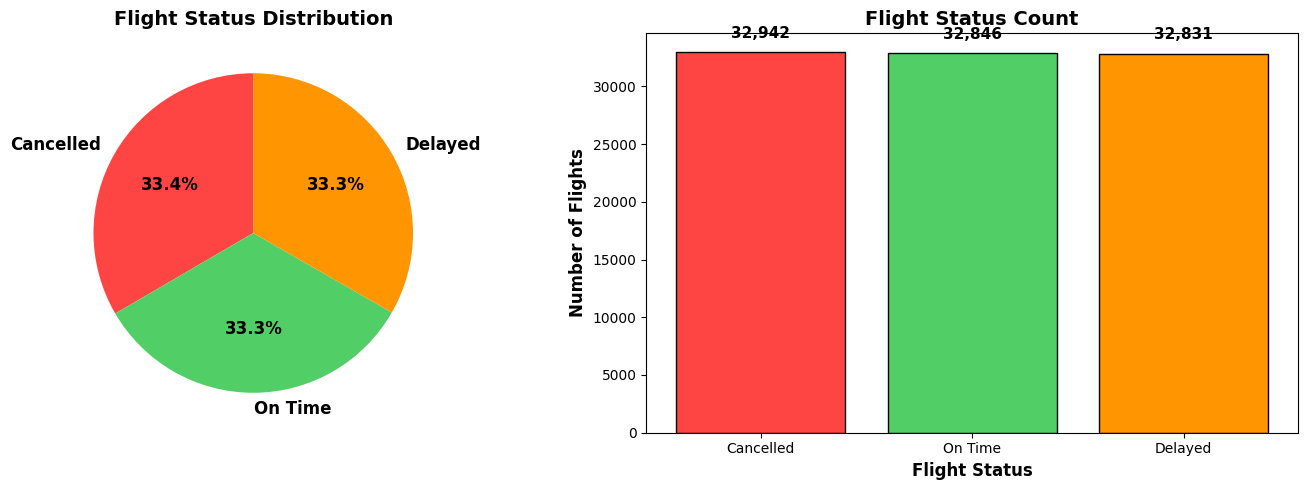

In [23]:
# Calculate percentage of delayed flights
import matplotlib.pyplot as plt
import seaborn as sns

# Get flight status counts
total_flights = len(df)
delayed_flights = df[df['Flight Status'] == 'Delayed'].shape[0]
on_time_flights = df[df['Flight Status'] == 'On Time'].shape[0]

delay_percentage = (delayed_flights / total_flights) * 100
on_time_percentage = (on_time_flights / total_flights) * 100

print(f"Total Flights: {total_flights:,}")
print(f"Delayed Flights: {delayed_flights:,} ({delay_percentage:.2f}%)")
print(f"On-Time Flights: {on_time_flights:,} ({on_time_percentage:.2f}%)")

# Visualize with pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
status_counts = df['Flight Status'].value_counts()
# Assign colors: Cancelled=Red, On Time=Green, Delayed=Orange
colors = ['#ff4444', '#51cf66', '#ff9500']  # Red, Green, Orange
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Flight Status Distribution', fontsize=14, weight='bold')

# Bar chart
axes[1].bar(status_counts.index, status_counts.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Flight Status', fontsize=12, weight='bold')
axes[1].set_ylabel('Number of Flights', fontsize=12, weight='bold')
axes[1].set_title('Flight Status Count', fontsize=14, weight='bold')
for i, v in enumerate(status_counts.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

**BALANCED DATASET GOOD ENOUGH TO TRAIN**

### 2. Which airports have more delays?

In [24]:
# Analyze delays by airport
airport_delays = df.groupby('Airport Name')['Flight Status'].apply(
    lambda x: (x == 'Delayed').sum()
).sort_values(ascending=False)

airport_total = df['Airport Name'].value_counts()
airport_delay_rate = (airport_delays / airport_total * 100).sort_values(ascending=False)

print("Top 10 Airports with Most Delayed Flights (count):")
print("="*60)
for i, (airport, count) in enumerate(airport_delays.head(10).items(), 1):
    total = airport_total[airport]
    rate = airport_delay_rate[airport]
    print(f"{i:2d}. {airport:30s} - {count:4d} delays ({rate:.1f}% of {total} flights)")

print("\n" + "="*60)
print("\nTop 10 Airports with Highest Delay Rate (%):")
print("="*60)
for i, (airport, rate) in enumerate(airport_delay_rate.head(10).items(), 1):
    count = airport_delays[airport]
    total = airport_total[airport]
    print(f"{i:2d}. {airport:30s} - {rate:.1f}% ({count} of {total} flights)")

Top 10 Airports with Most Delayed Flights (count):
 1. Santa Maria Airport            -   17 delays (44.7% of 38 flights)
 2. Santa Rosa Airport             -   16 delays (57.1% of 28 flights)
 3. San Pedro Airport              -   15 delays (34.9% of 43 flights)
 4. Santa Ana Airport              -   14 delays (40.0% of 35 flights)
 5. Visby Airport                  -   13 delays (61.9% of 21 flights)
 6. Lake County Airport            -   13 delays (48.1% of 27 flights)
 7. Sawan Airport                  -   13 delays (54.2% of 24 flights)
 8. La Florida Airport             -   12 delays (44.4% of 27 flights)
 9. Chu Lai International Airport  -   12 delays (63.2% of 19 flights)
10. Grant County Airport           -   12 delays (46.2% of 26 flights)


Top 10 Airports with Highest Delay Rate (%):
 1. Jefferson Municipal Airport    - 100.0% (4 of 4 flights)
 2. Batna Airport                  - 100.0% (3 of 3 flights)
 3. St Clair County Airport        - 100.0% (9 of 9 flights)
 4. Kasba

C:\Users\user\AppData\Local\Temp\ipykernel_27376\2184143879.py:26: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


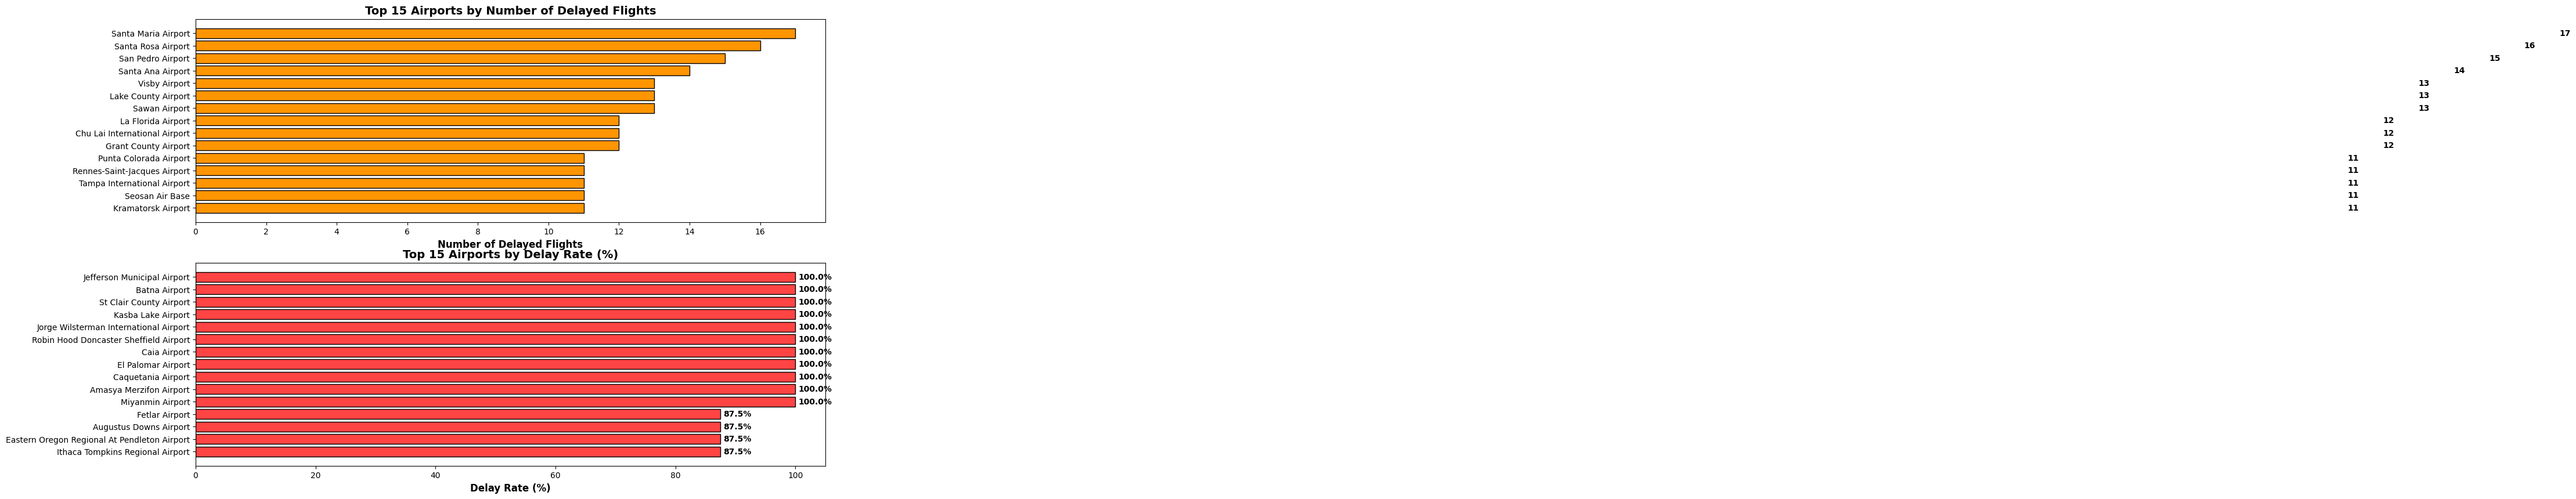

In [25]:
# Visualize airport delays
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top 15 airports by number of delays
top_airports_count = airport_delays.head(15)
axes[0].barh(range(len(top_airports_count)), top_airports_count.values, color='#ff9500', edgecolor='black')
axes[0].set_yticks(range(len(top_airports_count)))
axes[0].set_yticklabels(top_airports_count.index, fontsize=10)
axes[0].set_xlabel('Number of Delayed Flights', fontsize=12, weight='bold')
axes[0].set_title('Top 15 Airports by Number of Delayed Flights', fontsize=14, weight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(top_airports_count.values):
    axes[0].text(v + 50, i, str(v), va='center', fontsize=10, weight='bold')

# Top 15 airports by delay rate (%)
top_airports_rate = airport_delay_rate.head(15)
axes[1].barh(range(len(top_airports_rate)), top_airports_rate.values, color='#ff4444', edgecolor='black')
axes[1].set_yticks(range(len(top_airports_rate)))
axes[1].set_yticklabels(top_airports_rate.index, fontsize=10)
axes[1].set_xlabel('Delay Rate (%)', fontsize=12, weight='bold')
axes[1].set_title('Top 15 Airports by Delay Rate (%)', fontsize=14, weight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(top_airports_rate.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

We currently have two rankings:

By total delays (count) → favors big airports

By delay rate (%) → favors small airports

Neither is fair alone.

So we need a balanced scoring system. -----> weighted scoring system

In [34]:
print(f"Median number of flights per airport: {airport_stats['total_flights'].median():.2f}")


Median number of flights per airport: 11.00


In [32]:
overall_delay_rate = (df["Flight Status"] == "Delayed").mean()

airport_stats = df.groupby("Airport Name")["Flight Status"].agg(
    total_flights="count",
    delay_rate=lambda x: (x == "Delayed").mean()
).reset_index()

m = 11 # basian smoothing parameter (mean number of flights per airport)
C = overall_delay_rate

airport_stats["weighted_score"] = (
    (airport_stats["total_flights"] / (airport_stats["total_flights"] + m)) 
    * airport_stats["delay_rate"]
    + 
    (m / (airport_stats["total_flights"] + m)) 
    * C
)

airport_stats.sort_values("weighted_score", ascending=False)


,Airport Name,total_flights,delay_rate,weighted_score
7601,St Clair County Airport,9,1.000000,0.633099
1369,Caquetania Airport,7,1.000000,0.592332
2331,El Palomar Airport,6,1.000000,0.568352
837,Bentota River Waterdrome,15,0.733333,0.563922
7745,Sundsvall-Härnösand Airport,15,0.733333,0.563922
...,...,...,...,...
8702,West Wyalong Airport,13,0.000000,0.152583
2089,Dinangat Airport,13,0.000000,0.152583
1017,Boolgeeda,14,0.000000,0.146479
6036,Otu Airport,14,0.000000,0.146479


### 3. Does continent affect delay?

In [ ]:
# Analyze delay by continent
continent_stats = df.groupby('Continents')['Flight Status'].apply(
    lambda x: pd.Series({
        'Total Flights': len(x),
        'Delayed': (x == 'Delayed').sum(),
        'On Time': (x == 'On Time').sum(),
        'Cancelled': (x == 'Cancelled').sum(),
        'Delay Rate (%)': (x == 'Delayed').sum() / len(x) * 100
    })
).round(2)

print("Flight Status by Continent:")
print("="*70)
print(continent_stats.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Delay rate by continent
continents = continent_stats.index
delay_rates = continent_stats['Delay Rate (%)']
colors_cont = ['#ff9500' if rate == delay_rates.max() else '#4a90e2' for rate in delay_rates]

axes[0].bar(continents, delay_rates, color=colors_cont, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Continent', fontsize=12, weight='bold')
axes[0].set_ylabel('Delay Rate (%)', fontsize=12, weight='bold')
axes[0].set_title('Delay Rate by Continent', fontsize=14, weight='bold')
axes[0].axhline(y=delay_rates.mean(), color='red', linestyle='--', linewidth=2, label=f'Average: {delay_rates.mean():.1f}%')
axes[0].legend()
for i, v in enumerate(delay_rates):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=11, weight='bold')

# Stacked bar chart showing all statuses
status_data = continent_stats[['Delayed', 'On Time', 'Cancelled']]
x_pos = np.arange(len(continents))
axes[1].bar(x_pos, status_data['Cancelled'], label='Cancelled', color='#ff4444', edgecolor='black')
axes[1].bar(x_pos, status_data['On Time'], bottom=status_data['Cancelled'], 
            label='On Time', color='#51cf66', edgecolor='black')
axes[1].bar(x_pos, status_data['Delayed'], 
            bottom=status_data['Cancelled'] + status_data['On Time'],
            label='Delayed', color='#ff9500', edgecolor='black')
axes[1].set_xlabel('Continent', fontsize=12, weight='bold')
axes[1].set_ylabel('Number of Flights', fontsize=12, weight='bold')
axes[1].set_title('Flight Status Distribution by Continent', fontsize=14, weight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(continents)
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistical test
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df['Continents'], df['Flight Status'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\n{'='*70}")
print(f"Chi-Square Test for Independence:")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
if p_value < 0.05:
    print("✓ Continent DOES significantly affect flight delay (p < 0.05)")
else:
    print("✗ Continent does NOT significantly affect flight delay (p >= 0.05)")

### 4. Does pilot name affect delay? (Are some pilots less punctual?)

In [ ]:
# Analyze delay by pilot
pilot_stats = df.groupby('Pilot Name')['Flight Status'].apply(
    lambda x: pd.Series({
        'Total Flights': len(x),
        'Delayed': (x == 'Delayed').sum(),
        'Delay Rate (%)': (x == 'Delayed').sum() / len(x) * 100
    })
).round(2)

# Sort by delay rate
pilot_stats_sorted = pilot_stats.sort_values('Delay Rate (%)', ascending=False)

print(f"Total number of pilots: {len(pilot_stats)}")
print(f"Average flights per pilot: {pilot_stats['Total Flights'].mean():.1f}")
print(f"Average delay rate: {pilot_stats['Delay Rate (%)'].mean():.2f}%")
print(f"\nDelay rate range: {pilot_stats['Delay Rate (%)'].min():.1f}% - {pilot_stats['Delay Rate (%)'].max():.1f}%")

print("\n" + "="*70)
print("Top 10 Pilots with HIGHEST Delay Rate:")
print("="*70)
for i, (pilot, row) in enumerate(pilot_stats_sorted.head(10).iterrows(), 1):
    print(f"{i:2d}. {pilot:25s} - {row['Delay Rate (%)']:5.1f}% ({int(row['Delayed'])} of {int(row['Total Flights'])} flights)")

print("\n" + "="*70)
print("Top 10 Pilots with LOWEST Delay Rate:")
print("="*70)
for i, (pilot, row) in enumerate(pilot_stats_sorted.tail(10).iloc[::-1].iterrows(), 1):
    print(f"{i:2d}. {pilot:25s} - {row['Delay Rate (%)']:5.1f}% ({int(row['Delayed'])} of {int(row['Total Flights'])} flights)")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribution of delay rates
axes[0, 0].hist(pilot_stats['Delay Rate (%)'], bins=30, color='#4a90e2', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(pilot_stats['Delay Rate (%)'].mean(), color='red', linestyle='--', linewidth=2, 
                    label=f'Mean: {pilot_stats["Delay Rate (%)"].mean():.1f}%')
axes[0, 0].set_xlabel('Delay Rate (%)', fontsize=12, weight='bold')
axes[0, 0].set_ylabel('Number of Pilots', fontsize=12, weight='bold')
axes[0, 0].set_title('Distribution of Pilot Delay Rates', fontsize=14, weight='bold')
axes[0, 0].legend()

# Top 15 pilots with highest delay rate
top_15_pilots = pilot_stats_sorted.head(15)
axes[0, 1].barh(range(len(top_15_pilots)), top_15_pilots['Delay Rate (%)'], color='#ff4444', edgecolor='black')
axes[0, 1].set_yticks(range(len(top_15_pilots)))
axes[0, 1].set_yticklabels(top_15_pilots.index, fontsize=9)
axes[0, 1].set_xlabel('Delay Rate (%)', fontsize=12, weight='bold')
axes[0, 1].set_title('Top 15 Pilots with Highest Delay Rate', fontsize=14, weight='bold')
axes[0, 1].invert_yaxis()

# Top 15 pilots with lowest delay rate
bottom_15_pilots = pilot_stats_sorted.tail(15).iloc[::-1]
axes[1, 0].barh(range(len(bottom_15_pilots)), bottom_15_pilots['Delay Rate (%)'], color='#51cf66', edgecolor='black')
axes[1, 0].set_yticks(range(len(bottom_15_pilots)))
axes[1, 0].set_yticklabels(bottom_15_pilots.index, fontsize=9)
axes[1, 0].set_xlabel('Delay Rate (%)', fontsize=12, weight='bold')
axes[1, 0].set_title('Top 15 Pilots with Lowest Delay Rate', fontsize=14, weight='bold')
axes[1, 0].invert_yaxis()

# Scatter plot: flights vs delay rate
axes[1, 1].scatter(pilot_stats['Total Flights'], pilot_stats['Delay Rate (%)'], 
                   alpha=0.5, color='#4a90e2', edgecolors='black', s=50)
axes[1, 1].axhline(pilot_stats['Delay Rate (%)'].mean(), color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Total Flights', fontsize=12, weight='bold')
axes[1, 1].set_ylabel('Delay Rate (%)', fontsize=12, weight='bold')
axes[1, 1].set_title('Pilot Flights vs Delay Rate', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

# Statistical analysis
print(f"\n{'='*70}")
print("Statistical Summary:")
print(f"Standard Deviation of Delay Rates: {pilot_stats['Delay Rate (%)'].std():.2f}%")
print(f"Coefficient of Variation: {(pilot_stats['Delay Rate (%)'].std() / pilot_stats['Delay Rate (%)'].mean() * 100):.2f}%")

### 5. Does month affect delay?

In [ ]:
# Analyze delay by month
month_stats = df.groupby('Month')['Flight Status'].apply(
    lambda x: pd.Series({
        'Total Flights': len(x),
        'Delayed': (x == 'Delayed').sum(),
        'On Time': (x == 'On Time').sum(),
        'Cancelled': (x == 'Cancelled').sum(),
        'Delay Rate (%)': (x == 'Delayed').sum() / len(x) * 100
    })
).round(2)

month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

print("Flight Status by Month:")
print("="*70)
for month in sorted(month_stats.index):
    row = month_stats.loc[month]
    print(f"{month_names[month]:3s} ({month:2d}): {int(row['Total Flights']):5d} flights | "
          f"Delayed: {int(row['Delayed']):5d} ({row['Delay Rate (%)']:5.1f}%) | "
          f"On Time: {int(row['On Time']):5d} | Cancelled: {int(row['Cancelled']):5d}")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Line plot for delay rate by month
months = sorted(month_stats.index)
delay_rates_month = [month_stats.loc[m, 'Delay Rate (%)'] for m in months]
month_labels = [month_names[m] for m in months]

axes[0, 0].plot(month_labels, delay_rates_month, marker='o', linewidth=2.5, 
                markersize=8, color='#ff9500', markerfacecolor='#ff4444', markeredgewidth=2, markeredgecolor='black')
axes[0, 0].axhline(y=np.mean(delay_rates_month), color='red', linestyle='--', linewidth=2, 
                    label=f'Average: {np.mean(delay_rates_month):.1f}%')
axes[0, 0].set_xlabel('Month', fontsize=12, weight='bold')
axes[0, 0].set_ylabel('Delay Rate (%)', fontsize=12, weight='bold')
axes[0, 0].set_title('Delay Rate by Month', fontsize=14, weight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Bar chart for delay rate by month
colors_month = ['#ff4444' if rate == max(delay_rates_month) else '#4a90e2' for rate in delay_rates_month]
axes[0, 1].bar(month_labels, delay_rates_month, color=colors_month, edgecolor='black', linewidth=1.5)
axes[0, 1].set_xlabel('Month', fontsize=12, weight='bold')
axes[0, 1].set_ylabel('Delay Rate (%)', fontsize=12, weight='bold')
axes[0, 1].set_title('Delay Rate by Month (Bar)', fontsize=14, weight='bold')
for i, v in enumerate(delay_rates_month):
    axes[0, 1].text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, weight='bold')

# Stacked bar chart
status_data_month = month_stats[['Cancelled', 'On Time', 'Delayed']].loc[months]
x_pos = np.arange(len(months))
axes[1, 0].bar(x_pos, status_data_month['Cancelled'], label='Cancelled', color='#ff4444', edgecolor='black')
axes[1, 0].bar(x_pos, status_data_month['On Time'], bottom=status_data_month['Cancelled'], 
               label='On Time', color='#51cf66', edgecolor='black')
axes[1, 0].bar(x_pos, status_data_month['Delayed'], 
               bottom=status_data_month['Cancelled'] + status_data_month['On Time'],
               label='Delayed', color='#ff9500', edgecolor='black')
axes[1, 0].set_xlabel('Month', fontsize=12, weight='bold')
axes[1, 0].set_ylabel('Number of Flights', fontsize=12, weight='bold')
axes[1, 0].set_title('Flight Status Distribution by Month', fontsize=14, weight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(month_labels)
axes[1, 0].legend()

# Heatmap-style visualization
axes[1, 1].bar(month_labels, month_stats.loc[months, 'Total Flights'], color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Month', fontsize=12, weight='bold')
axes[1, 1].set_ylabel('Total Number of Flights', fontsize=12, weight='bold')
axes[1, 1].set_title('Total Flights by Month', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

# Statistical test
print(f"\n{'='*70}")
contingency_table_month = pd.crosstab(df['Month'], df['Flight Status'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table_month)
print(f"Chi-Square Test for Independence:")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
if p_value < 0.05:
    print("✓ Month DOES significantly affect flight delay (p < 0.05)")
else:
    print("✗ Month does NOT significantly affect flight delay (p >= 0.05)")

### 6. Does age correlate with delay?

In [ ]:
# Analyze relationship between age and delay
age_stats = df.groupby('Age')['Flight Status'].apply(
    lambda x: pd.Series({
        'Total Flights': len(x),
        'Delayed': (x == 'Delayed').sum(),
        'Delay Rate (%)': (x == 'Delayed').sum() / len(x) * 100
    })
).round(2)

print(f"Age range in dataset: {df['Age'].min()} - {df['Age'].max()}")
print(f"Average age: {df['Age'].mean():.1f}")
print(f"Median age: {df['Age'].median():.1f}")

# Create age groups for better analysis
df['Age Group'] = pd.cut(df['Age'], bins=[0, 18, 30, 45, 60, 100], 
                         labels=['0-18', '19-30', '31-45', '46-60', '60+'])

age_group_stats = df.groupby('Age Group')['Flight Status'].apply(
    lambda x: pd.Series({
        'Total Flights': len(x),
        'Delayed': (x == 'Delayed').sum(),
        'On Time': (x == 'On Time').sum(),
        'Cancelled': (x == 'Cancelled').sum(),
        'Delay Rate (%)': (x == 'Delayed').sum() / len(x) * 100
    })
).round(2)

print("\n" + "="*70)
print("Flight Status by Age Group:")
print("="*70)
print(age_group_stats.to_string())

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Scatter plot: Age vs Delay Rate
axes[0, 0].scatter(age_stats.index, age_stats['Delay Rate (%)'], alpha=0.6, 
                   s=age_stats['Total Flights']*2, color='#4a90e2', edgecolors='black')
axes[0, 0].set_xlabel('Age', fontsize=12, weight='bold')
axes[0, 0].set_ylabel('Delay Rate (%)', fontsize=12, weight='bold')
axes[0, 0].set_title('Age vs Delay Rate (bubble size = # of flights)', fontsize=14, weight='bold')
axes[0, 0].axhline(y=age_stats['Delay Rate (%)'].mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'Average: {age_stats["Delay Rate (%)"].mean():.1f}%')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Bar chart by age group
age_groups = age_group_stats.index
delay_rates_age = age_group_stats['Delay Rate (%)']
axes[0, 1].bar(age_groups, delay_rates_age, color='#ff9500', edgecolor='black', linewidth=1.5)
axes[0, 1].set_xlabel('Age Group', fontsize=12, weight='bold')
axes[0, 1].set_ylabel('Delay Rate (%)', fontsize=12, weight='bold')
axes[0, 1].set_title('Delay Rate by Age Group', fontsize=14, weight='bold')
axes[0, 1].axhline(y=delay_rates_age.mean(), color='red', linestyle='--', linewidth=2)
for i, v in enumerate(delay_rates_age):
    axes[0, 1].text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontsize=11, weight='bold')

# Stacked bar chart by age group
status_data_age = age_group_stats[['Cancelled', 'On Time', 'Delayed']]
x_pos = np.arange(len(age_groups))
axes[1, 0].bar(x_pos, status_data_age['Cancelled'], label='Cancelled', color='#ff4444', edgecolor='black')
axes[1, 0].bar(x_pos, status_data_age['On Time'], bottom=status_data_age['Cancelled'], 
               label='On Time', color='#51cf66', edgecolor='black')
axes[1, 0].bar(x_pos, status_data_age['Delayed'], 
               bottom=status_data_age['Cancelled'] + status_data_age['On Time'],
               label='Delayed', color='#ff9500', edgecolor='black')
axes[1, 0].set_xlabel('Age Group', fontsize=12, weight='bold')
axes[1, 0].set_ylabel('Number of Flights', fontsize=12, weight='bold')
axes[1, 0].set_title('Flight Status Distribution by Age Group', fontsize=14, weight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(age_groups)
axes[1, 0].legend()

# Box plot
delayed_ages = df[df['Flight Status'] == 'Delayed']['Age']
ontime_ages = df[df['Flight Status'] == 'On Time']['Age']
cancelled_ages = df[df['Flight Status'] == 'Cancelled']['Age']

bp = axes[1, 1].boxplot([delayed_ages, ontime_ages, cancelled_ages], 
                        labels=['Delayed', 'On Time', 'Cancelled'],
                        patch_artist=True, showmeans=True)
colors_box = ['#ff9500', '#51cf66', '#ff4444']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)
axes[1, 1].set_ylabel('Age', fontsize=12, weight='bold')
axes[1, 1].set_title('Age Distribution by Flight Status', fontsize=14, weight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Correlation analysis
from scipy.stats import pearsonr, spearmanr
df_delayed_binary = (df['Flight Status'] == 'Delayed').astype(int)
pearson_corr, pearson_p = pearsonr(df['Age'], df_delayed_binary)
spearman_corr, spearman_p = spearmanr(df['Age'], df_delayed_binary)

print(f"\n{'='*70}")
print("Correlation Analysis:")
print(f"Pearson Correlation: {pearson_corr:.4f} (p-value: {pearson_p:.6f})")
print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {spearman_p:.6f})")

if abs(pearson_corr) < 0.1:
    strength = "very weak or no"
elif abs(pearson_corr) < 0.3:
    strength = "weak"
elif abs(pearson_corr) < 0.5:
    strength = "moderate"
else:
    strength = "strong"

if pearson_p < 0.05:
    print(f"✓ There is a statistically significant but {strength} correlation between age and delay")
else:
    print(f"✗ No statistically significant correlation between age and delay")

# Chi-square test for age groups
contingency_table_age = pd.crosstab(df['Age Group'], df['Flight Status'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table_age)
print(f"\nChi-Square Test for Age Groups:")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
if p_value < 0.05:
    print("✓ Age group DOES significantly affect flight delay (p < 0.05)")
else:
    print("✗ Age group does NOT significantly affect flight delay (p >= 0.05)")